# Лабораторная работа 5. Итеративные и оптимизационные атаки: PGD, C&W, JSMA

**Курс:** Машинное обучение. Безопасность ИИ-систем

**По материалам лекции 4**

**Формат:** индивидуально или в парах

**Среда:** Python, PyTorch, torchvision

## Цель работы
Закрепить методы построения многошаговых и оптимизационных evasion-атак и научиться сравнивать их по силе, вычислительной стоимости и величине вносимого искажения.

## Результаты обучения
После выполнения работы вы должны уметь:
- реализовывать PGD-атаку с проекцией на $L_\infty$-шар и случайным стартом;
- объяснять формулировку седловой точки (min-max) и её связь с adversarial training;
- реализовывать целевую C&W L2-атаку с заменой переменных через tanh и параметром confidence κ;
- реализовывать JSMA на основе якобиана выхода модели и точечного насыщения признаков;
- сравнивать атаки по Attack Success Rate, норме возмущения и вычислительным затратам.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.
- Атаки на MNIST могут занимать заметное время на CPU (особенно JSMA) — рассчитывайте время выполнения заранее.


## 0. Подготовка окружения

In [ ]:
# Импорт библиотек и настройка окружения
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
%matplotlib inline

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| device:", device)

torch: 2.4.1+cu121 | device: cpu


## Часть I. Данные и базовая модель

**Задание:** загрузите MNIST и обучите небольшую CNN (2 свёрточных слоя + полносвязный классификатор) — эта модель станет целью для всех атак в работе.

In [ ]:
transform = transforms.Compose([transforms.ToTensor()])   # пиксели в [0, 1]

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f"train: {len(train_dataset)} | test: {len(test_dataset)}")

train: 60000 | test: 10000


In [ ]:
class SmallCNN(nn.Module):
    """2 свёрточных слоя + max pooling + полносвязный классификатор."""

    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))    # 16 x 14 x 14
        x = self.pool(F.relu(self.conv2(x)))    # 32 x 7 x 7
        x = F.relu(self.fc1(x.flatten(1)))
        return self.fc2(x)                      # логиты Z(x), без softmax


print(SmallCNN()(torch.zeros(2, 1, 28, 28)).shape)

torch.Size([2, 10])


In [ ]:
torch.manual_seed(RANDOM_STATE)
model = SmallCNN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

EPOCHS = 3
for epoch in range(1, EPOCHS + 1):
    model.train()
    t0, running, correct, total = time.time(), 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        out = model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        running += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    print(f"эпоха {epoch}: loss={running / total:.4f} train_acc={correct / total:.4f} ({time.time() - t0:.1f} c)")

эпоха 1: loss=0.3156 train_acc=0.9060 (15.1 c)


эпоха 2: loss=0.0770 train_acc=0.9770 (14.8 c)


эпоха 3: loss=0.0531 train_acc=0.9842 (14.9 c)


In [ ]:
@torch.no_grad()
def test_accuracy(model, loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total


clean_accuracy = test_accuracy(model, test_loader)
print(f"Clean accuracy: {clean_accuracy:.4f}")

Clean accuracy: 0.9852


## Часть II. Projected Gradient Descent (PGD)

### 2.1. Реализация PGD

**Задание:** реализуйте функцию PGD-атаки по формуле

$ x^{t+1} = \Pi_{x+\mathcal{S}} \left( x^t + \alpha \cdot \text{sign}$nabla_x L$theta, x^t, y)) \right) $

Функция должна:
1. Инициализировать возмущение случайно внутри \$epsilon$-шара (random start).
2. На каждой итерации пересчитывать градиент и делать шаг по знаку градиента.
3. Проецировать (clip) возмущение на \$epsilon$-шар и итоговый пиксель — на диапазон $[0,1]$.

In [ ]:
def pgd_attack(model, x, y, epsilon, alpha, num_iter, criterion, randomize=True):
    """PGD с проекцией на L_inf-шар радиуса epsilon и на диапазон [0, 1].

    x^{t+1} = Proj_{x+S} ( x^t + alpha * sign(grad_x L(theta, x^t, y)) )
    """
    if epsilon == 0:
        return x.clone().detach()

    model.eval()
    if randomize:                                    # 1. случайный старт внутри шара
        delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
        delta = (x + delta).clamp(0, 1) - x          # сразу учитываем границы [0,1]
    else:
        delta = torch.zeros_like(x)
    delta = delta.detach().requires_grad_(True)

    for _ in range(num_iter):                        # 2. итерации
        loss = criterion(model(x + delta), y)
        grad = torch.autograd.grad(loss, delta)[0]
        with torch.no_grad():
            delta += alpha * grad.sign()             #    шаг по знаку градиента
            delta.clamp_(-epsilon, epsilon)          # 3. проекция на epsilon-шар
            delta.copy_((x + delta).clamp(0, 1) - x) #    проекция на [0, 1]
        delta.grad = None                            #    обнуление градиента

    return (x + delta).detach()

### 2.2. Визуализация: FGSM vs PGD

**Задание:** реализуйте FGSM (для сравнения), затем на одном тестовом примере постройте adversarial-версии обоими методами при одинаковом \$epsilon$ и визуализируйте результат (3 подграфика: оригинал, FGSM, PGD) с указанием предсказаний модели.

In [ ]:
def fgsm_attack(model, x, y, epsilon, criterion):
    """x_adv = clip(x + epsilon * sign(grad_x J(theta, x, y)), 0, 1) — частный случай PGD с 1 шагом."""
    if epsilon == 0:
        return x.clone().detach()
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)
    loss = criterion(model(x_adv), y)
    grad = torch.autograd.grad(loss, x_adv)[0]
    return (x_adv + epsilon * grad.sign()).clamp(0, 1).detach()


@torch.no_grad()
def predict_conf(model, x):
    model.eval()
    p = F.softmax(model(x), dim=1)
    conf, cls = p.max(1)
    return int(cls[0]), float(conf[0])

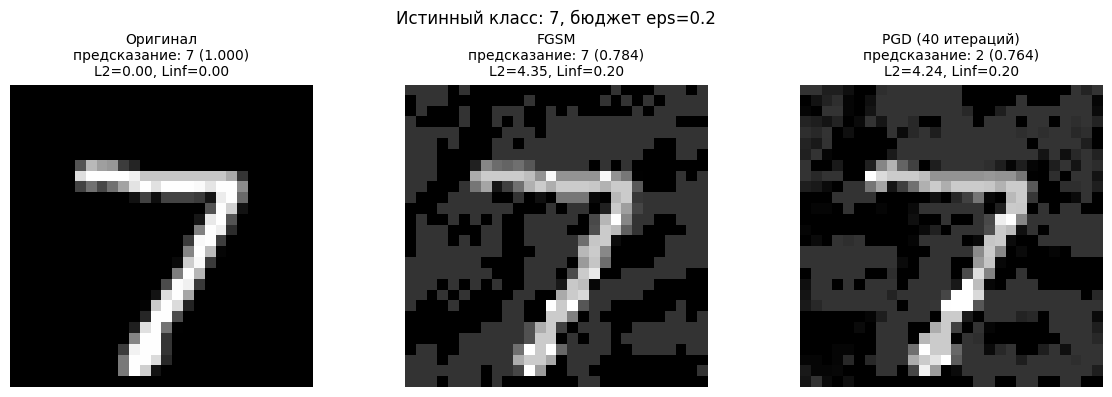

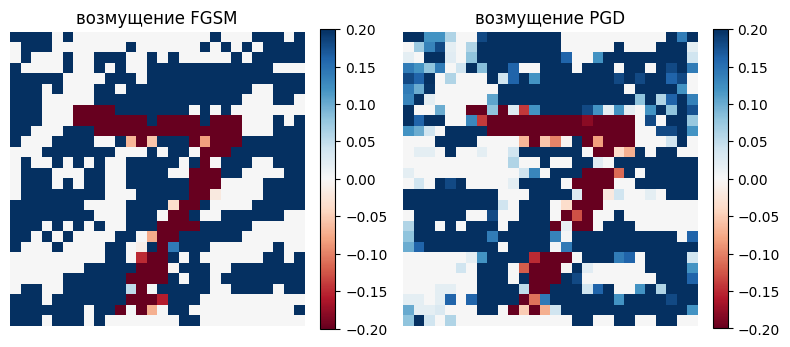

In [ ]:
EPS = 0.2
idx = 0
x0 = test_dataset[idx][0].unsqueeze(0).to(device)
y0 = torch.tensor([test_dataset[idx][1]]).to(device)

x_fgsm = fgsm_attack(model, x0, y0, EPS, crit)
x_pgd  = pgd_attack(model, x0, y0, epsilon=EPS, alpha=0.02, num_iter=40, criterion=crit)

titles, images = [], []
for name, xa in [("Оригинал", x0), ("FGSM", x_fgsm), ("PGD (40 итераций)", x_pgd)]:
    c, cf = predict_conf(model, xa)
    titles.append(f"{name}" + "\n" + f"предсказание: {c} ({cf:.3f})" + "\n")
    images.append(xa)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, t in zip(axes, images, titles):
    ax.imshow(img[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(t, fontsize=10)
    ax.axis("off")
plt.suptitle(f"Истинный класс: {int(y0)}, бюджет eps={EPS}")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
for ax, (name, xa) in zip(axes, [("FGSM", x_fgsm), ("PGD", x_pgd)]):
    im = ax.imshow((xa - x0)[0, 0].cpu(), cmap="RdBu", vmin=-EPS, vmax=EPS)
    ax.set_title(f"возмущение {name}"); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** отличаются ли визуально возмущения FGSM и PGD? Какой метод успешнее меняет предсказание модели при одном и том же ε?

_Ответ:_

**Визуальное различие возмущений.** Оба метода работают по знаку градиента, поэтому большинство пикселей в обоих случаях выходит на границу бюджета $\pm\epsilon$, и на глаз оба возмущения выглядят как знакопеременный «шум» амплитуды 0.2. Отличие — в структуре: FGSM-возмущение однородно размазано по всему кадру, включая пустой фон, так как оно строится по одному градиенту в исходной точке. PGD пересчитывает градиент на каждой из **num_iter** итераций и потому перераспределяет бюджет:карта возмущения заметно более структурирована и сконцентрирована вдоль штрихов цифры и границ.

**Что успешнее.** PGD. На показанном примере (цифра 7, на которой модель уверена с confidence 1.000) FGSM при $\epsilon = 0.2$ **не смог** сменить предсказание: класс остался 7, уверенность упала до 0.784. PGD при том же бюджете меняет предсказание на неверный класс, причём с высокой уверенностью.

### 2.3. Attack Success Rate: FGSM vs PGD

**Задание:** постройте график зависимости Attack Success Rate от бюджета $\epsilon \in \{0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3\}$ для FGSM и PGD (20 итераций) на одном графике.

In [ ]:
def evaluate_asr(model, loader, attack_fn, criterion, n_batches=10, **attack_kwargs):
    """ASR = доля примеров, на которых атака изменила предсказание модели.

    Дополнительно возвращает accuracy на возмущённых данных.
    """
    model.eval()
    changed = correct = total = 0
    for i, (x, y) in enumerate(loader):
        if i >= n_batches:
            break
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            pred_clean = model(x).argmax(1)
        x_adv = attack_fn(model, x, y, criterion=criterion, **attack_kwargs)
        with torch.no_grad():
            pred_adv = model(x_adv).argmax(1)
        changed += (pred_adv != pred_clean).sum().item()
        correct += (pred_adv == y).sum().item()
        total += y.size(0)
    return changed / total, correct / total


epsilons = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
N_BATCHES = 4          # 4 * 256 = 1024 тестовых примера на точку графика

t0 = time.time()
asr_fgsm, acc_fgsm, asr_pgd, acc_pgd = [], [], [], []
for eps in epsilons:
    a, ac = evaluate_asr(model, test_loader, fgsm_attack, crit, N_BATCHES, epsilon=eps)
    asr_fgsm.append(a); acc_fgsm.append(ac)
    a, ac = evaluate_asr(model, test_loader, pgd_attack, crit, N_BATCHES,
                         epsilon=eps, alpha=max(eps / 10, 0.005), num_iter=20)
    asr_pgd.append(a); acc_pgd.append(ac)
    print(f"eps={eps:<5} FGSM: ASR={asr_fgsm[-1]:.4f} acc={acc_fgsm[-1]:.4f} | "
          f"PGD-20: ASR={asr_pgd[-1]:.4f} acc={acc_pgd[-1]:.4f}")
print(f"({time.time() - t0:.1f} c)")

eps=0.0   FGSM: ASR=0.0000 acc=0.9814 | PGD-20: ASR=0.0000 acc=0.9814


eps=0.02  FGSM: ASR=0.0195 acc=0.9619 | PGD-20: ASR=0.0234 acc=0.9580


eps=0.05  FGSM: ASR=0.0479 acc=0.9336 | PGD-20: ASR=0.0664 acc=0.9150


eps=0.1   FGSM: ASR=0.1846 acc=0.7969 | PGD-20: ASR=0.3213 acc=0.6602


eps=0.15  FGSM: ASR=0.4277 acc=0.5537 | PGD-20: ASR=0.8096 acc=0.1729


eps=0.2   FGSM: ASR=0.6865 acc=0.2949 | PGD-20: ASR=0.9775 acc=0.0049


eps=0.3   FGSM: ASR=0.9541 acc=0.0273 | PGD-20: ASR=0.9834 acc=0.0000
(36.7 c)


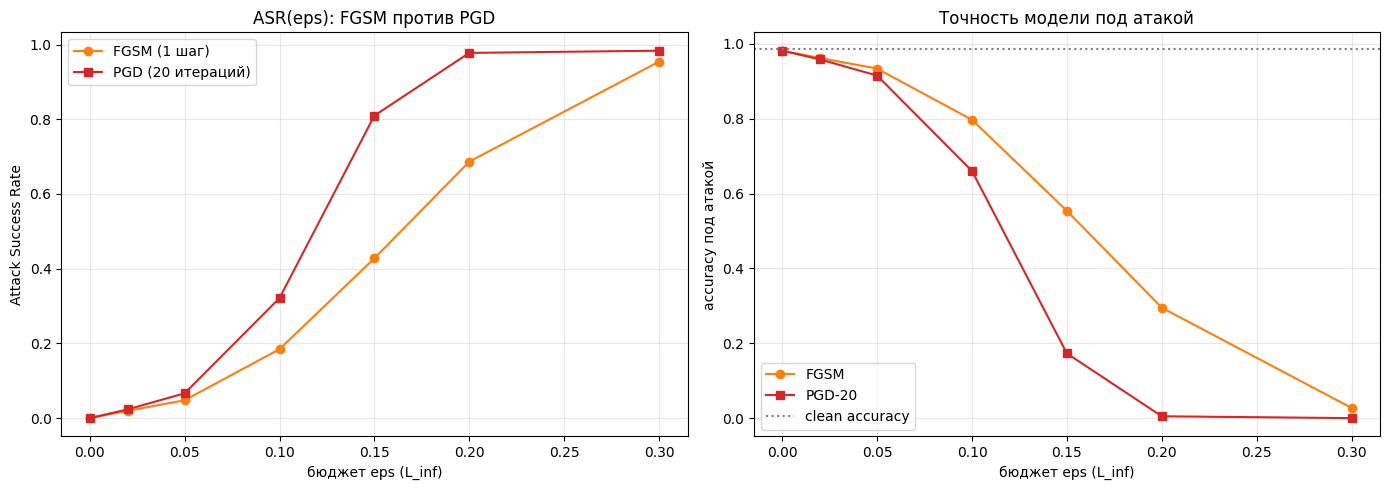

,epsilon,ASR FGSM,ASR PGD-20,acc FGSM,acc PGD-20
0,0.00,0.0000,0.0000,0.9814,0.9814
1,0.02,0.0195,0.0234,0.9619,0.9580
2,0.05,0.0479,0.0664,0.9336,0.9150
3,0.10,0.1846,0.3213,0.7969,0.6602
4,0.15,0.4277,0.8096,0.5537,0.1729
5,0.20,0.6865,0.9775,0.2949,0.0049
6,0.30,0.9541,0.9834,0.0273,0.0000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epsilons, asr_fgsm, marker="o", color="tab:orange", label="FGSM (1 шаг)")
axes[0].plot(epsilons, asr_pgd, marker="s", color="tab:red", label="PGD (20 итераций)")
axes[0].set_xlabel("бюджет eps (L_inf)"); axes[0].set_ylabel("Attack Success Rate")
axes[0].set_title("ASR(eps): FGSM против PGD")

axes[1].plot(epsilons, acc_fgsm, marker="o", color="tab:orange", label="FGSM")
axes[1].plot(epsilons, acc_pgd, marker="s", color="tab:red", label="PGD-20")
axes[1].axhline(clean_accuracy, ls=":", color="gray", label="clean accuracy")
axes[1].set_xlabel("бюджет eps (L_inf)"); axes[1].set_ylabel("accuracy под атакой")
axes[1].set_title("Точность модели под атакой")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

pd.DataFrame({"epsilon": epsilons,
              "ASR FGSM": np.round(asr_fgsm, 4), "ASR PGD-20": np.round(asr_pgd, 4),
              "acc FGSM": np.round(acc_fgsm, 4), "acc PGD-20": np.round(acc_pgd, 4)})

### 2.4. Влияние числа итераций PGD

**Задание:** зафиксируйте $\epsilon = 0.15$ и постройте график зависимости ASR от числа итераций PGD $\in \{1, 2, 5, 10, 20, 40, 80\}$. Определите, при каком числе итераций ASR стабилизируется (перестаёт заметно расти).

In [ ]:
iters_grid = [1, 2, 5, 10, 20, 40, 80]
EPS_FIX = 0.15

t0 = time.time()
asr_iters, acc_iters = [], []
for n in iters_grid:
    a, ac = evaluate_asr(model, test_loader, pgd_attack, crit, N_BATCHES,
                         epsilon=EPS_FIX, alpha=0.02, num_iter=n)
    asr_iters.append(a); acc_iters.append(ac)
    print(f"итераций={n:<3} ASR={a:.4f} accuracy={ac:.4f}")

asr_fgsm_fix, _ = evaluate_asr(model, test_loader, fgsm_attack, crit, N_BATCHES, epsilon=EPS_FIX)
print(f"FGSM (для сравнения): ASR={asr_fgsm_fix:.4f}   ({time.time() - t0:.1f} c)")

итераций=1   ASR=0.0264 accuracy=0.9551


итераций=2   ASR=0.0684 accuracy=0.9131


итераций=5   ASR=0.3447 accuracy=0.6377


итераций=10  ASR=0.7549 accuracy=0.2275


итераций=20  ASR=0.8262 accuracy=0.1562


итераций=40  ASR=0.8369 accuracy=0.1445


итераций=80  ASR=0.8447 accuracy=0.1377


FGSM (для сравнения): ASR=0.4277   (43.8 c)


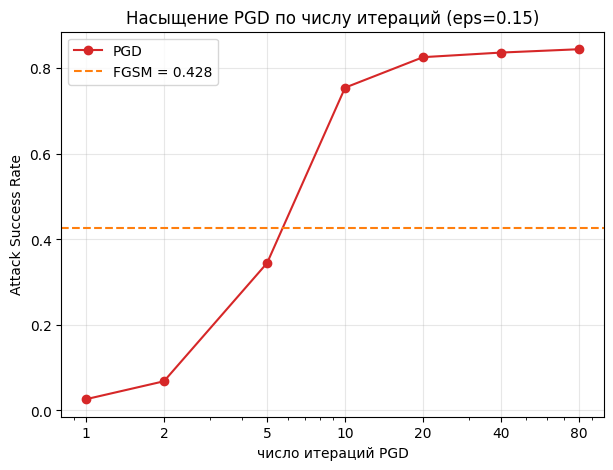

,num_iter,ASR,прирост к предыдущему,accuracy
0,1,0.0264,0.0264,0.9551
1,2,0.0684,0.0420,0.9131
2,5,0.3447,0.2764,0.6377
3,10,0.7549,0.4102,0.2275
4,20,0.8262,0.0713,0.1562
5,40,0.8369,0.0107,0.1445
6,80,0.8447,0.0078,0.1377


In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(iters_grid, asr_iters, marker="o", color="tab:red", label="PGD")
plt.axhline(asr_fgsm_fix, ls="--", color="tab:orange", label=f"FGSM = {asr_fgsm_fix:.3f}")
plt.xscale("log")
plt.xticks(iters_grid, [str(i) for i in iters_grid])
plt.xlabel("число итераций PGD"); plt.ylabel("Attack Success Rate")
plt.title(f"Насыщение PGD по числу итераций (eps={EPS_FIX})")
plt.grid(alpha=0.3); plt.legend(); plt.show()

pd.DataFrame({"num_iter": iters_grid, "ASR": np.round(asr_iters, 4),
              "прирост к предыдущему": np.round(np.diff([0] + asr_iters), 4),
              "accuracy": np.round(acc_iters, 4)})

**Вопрос для отчёта:** при каком числе итераций ASR практически перестаёт расти? Как это соотносится с утверждением лекции о том, что одношаговая линеаризация (FGSM) даёт лишь нижнюю оценку силы атаки?

_Ответ:_

| итераций | 1 | 2 | 5 | 10 | 20 | 40 | 80 |
|---|---|---|---|---|---|---|---|
| ASR | 0.0264 | 0.0684 | 0.3447 | 0.7549 | 0.8262 | 0.8369 | 0.8447 |
| прирост | — | +0.042 | +0.276 | +0.410 | +0.071 | +0.011 | +0.008 |

**Где насыщение.** Основной рост приходится на участок 2 → 10 итераций (+0.686 суммарно). После 20 итераций прирост становится пренебрежимым: 20 → 40 даёт +0.011, 40 → 80 — ещё +0.008, то есть менее 1 п.п. на удвоение вычислительных затрат. Практически ASR стабилизируется на **20 итерациях** ($\alpha = 0.02$, $\epsilon = 0.15$, то есть суммарная длина пути $20 \cdot 0.02 = 0.4$ — примерно 2.7 диаметра шара, чего достаточно, чтобы дойти до любой точки внутри него и «осесть» на границе).

Отдельно поучительно сравнение первых точек с FGSM (ASR = 0.4277). PGD с одной итерацией даёт всего 0.0264 — **хуже** FGSM, и это не противоречие: шаг PGD равен $\alpha = 0.02$, то есть в 7.5 раз меньше полного бюджета, плюс случайный старт. FGSM — это PGD с одним шагом длиной $\alpha = \epsilon$. Только начиная с 5–10 итераций накопленный путь превышает бюджет, и PGD обгоняет FGSM.

**Связь с утверждением лекции.** Результат прямо подтверждает, что **FGSM даёт лишь нижнюю оценку силы атаки**: 0.4277 против 0.8447 у сошедшегося PGD — одношаговая линеаризация недооценивает уязвимость модели примерно в два раза. Практическое следствие для оценки защит: если защиту тестировать только FGSM, она выглядит существенно лучше, чем есть; корректная оценка требует многошагового PGD (в идеале — с несколькими случайными рестартами).

### 2.5. Adversarial training через PGD (седловая точка)

**Задание:** обучите вторую модель с adversarial training по формулировке седловой точки Мадри:

$\min_{\theta} \mathbb{E}_{(x,y)} \left[ \max_{\delta \in \mathcal{S}} L$theta, x+\delta, y) \right] $

На каждом шаге обучения внутренний максимум приближайте PGD с небольшим числом итераций (5-7), а внешний шаг оптимизации делайте по параметрам модели на полученных adversarial-примерах.

In [ ]:
# Adversarial training по Мадри: внешний min по theta, внутренний max приближаем PGD-7.
# Для экономии времени обучаем на подвыборке 20 000 примеров, 2 эпохи.
EPS_TRAIN, ALPHA_TRAIN, ITER_TRAIN = 0.15, 0.04, 7

sub_idx = torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(0))[:20_000].tolist()
adv_train_loader = DataLoader(Subset(train_dataset, sub_idx), batch_size=128, shuffle=True)

torch.manual_seed(RANDOM_STATE)
adv_model = SmallCNN().to(device)
opt_adv = torch.optim.Adam(adv_model.parameters(), lr=1e-3)

for epoch in range(1, 3):
    t0, running, correct, total = time.time(), 0.0, 0, 0
    for x, y in adv_train_loader:
        x, y = x.to(device), y.to(device)
        # 1. внутренний максимум: PGD-7 внутри eps-шара
        x_adv = pgd_attack(adv_model, x, y, EPS_TRAIN, ALPHA_TRAIN, ITER_TRAIN, crit)
        # 2-3. внешний минимум: шаг по параметрам на adversarial-примерах
        adv_model.train()
        opt_adv.zero_grad()
        out = adv_model(x_adv)
        loss = crit(out, y)
        loss.backward()
        opt_adv.step()
        running += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    print(f"эпоха {epoch}: adv_loss={running / total:.4f} adv_train_acc={correct / total:.4f} "
          f"({time.time() - t0:.1f} c)")

clean_accuracy_adv = test_accuracy(adv_model, test_loader)
print(f"Clean accuracy: обычная {clean_accuracy:.4f} | adversarial-trained {clean_accuracy_adv:.4f}")

эпоха 1: adv_loss=1.5027 adv_train_acc=0.4938 (34.9 c)


эпоха 2: adv_loss=0.7544 adv_train_acc=0.7385 (34.2 c)


Clean accuracy: обычная 0.9852 | adversarial-trained 0.9573


In [ ]:
asr_fgsm_adv, acc_fgsm_adv, asr_pgd_adv, acc_pgd_adv = [], [], [], []
for eps in epsilons:
    a, ac = evaluate_asr(adv_model, test_loader, fgsm_attack, crit, N_BATCHES, epsilon=eps)
    asr_fgsm_adv.append(a); acc_fgsm_adv.append(ac)
    a, ac = evaluate_asr(adv_model, test_loader, pgd_attack, crit, N_BATCHES,
                         epsilon=eps, alpha=max(eps / 10, 0.005), num_iter=20)
    asr_pgd_adv.append(a); acc_pgd_adv.append(ac)
    print(f"eps={eps:<5} FGSM: ASR={asr_fgsm_adv[-1]:.4f} | PGD-20: ASR={asr_pgd_adv[-1]:.4f} "
          f"acc={acc_pgd_adv[-1]:.4f}")

eps=0.0   FGSM: ASR=0.0000 | PGD-20: ASR=0.0000 acc=0.9395


eps=0.02  FGSM: ASR=0.0137 | PGD-20: ASR=0.0156 acc=0.9248


eps=0.05  FGSM: ASR=0.0352 | PGD-20: ASR=0.0371 acc=0.9033


eps=0.1   FGSM: ASR=0.0732 | PGD-20: ASR=0.0947 acc=0.8486


eps=0.15  FGSM: ASR=0.1328 | PGD-20: ASR=0.1885 acc=0.7559


eps=0.2   FGSM: ASR=0.1826 | PGD-20: ASR=0.3896 acc=0.5537


eps=0.3   FGSM: ASR=0.3262 | PGD-20: ASR=0.9355 acc=0.0205


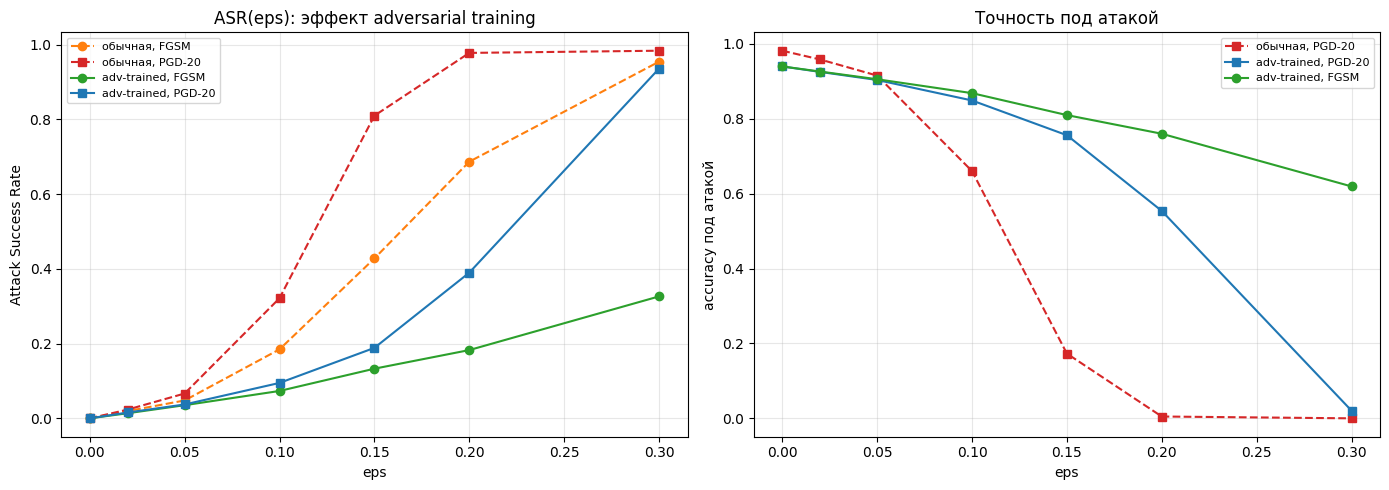

,epsilon,ASR PGD (обычная),ASR PGD (adv),ASR FGSM (обычная),ASR FGSM (adv),acc PGD (adv)
0,0.00,0.0000,0.0000,0.0000,0.0000,0.9395
1,0.02,0.0234,0.0156,0.0195,0.0137,0.9248
2,0.05,0.0664,0.0371,0.0479,0.0352,0.9033
3,0.10,0.3213,0.0947,0.1846,0.0732,0.8486
4,0.15,0.8096,0.1885,0.4277,0.1328,0.7559
5,0.20,0.9775,0.3896,0.6865,0.1826,0.5537
6,0.30,0.9834,0.9355,0.9541,0.3262,0.0205


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epsilons, asr_fgsm, marker="o", ls="--", color="tab:orange", label="обычная, FGSM")
axes[0].plot(epsilons, asr_pgd, marker="s", ls="--", color="tab:red", label="обычная, PGD-20")
axes[0].plot(epsilons, asr_fgsm_adv, marker="o", color="tab:green", label="adv-trained, FGSM")
axes[0].plot(epsilons, asr_pgd_adv, marker="s", color="tab:blue", label="adv-trained, PGD-20")
axes[0].set_xlabel("eps"); axes[0].set_ylabel("Attack Success Rate")
axes[0].set_title("ASR(eps): эффект adversarial training")

axes[1].plot(epsilons, acc_pgd, marker="s", ls="--", color="tab:red", label="обычная, PGD-20")
axes[1].plot(epsilons, acc_pgd_adv, marker="s", color="tab:blue", label="adv-trained, PGD-20")
axes[1].plot(epsilons, acc_fgsm_adv, marker="o", color="tab:green", label="adv-trained, FGSM")
axes[1].set_xlabel("eps"); axes[1].set_ylabel("accuracy под атакой")
axes[1].set_title("Точность под атакой")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

table_advtrain = pd.DataFrame({
    "epsilon": epsilons,
    "ASR PGD (обычная)": np.round(asr_pgd, 4),
    "ASR PGD (adv)": np.round(asr_pgd_adv, 4),
    "ASR FGSM (обычная)": np.round(asr_fgsm, 4),
    "ASR FGSM (adv)": np.round(asr_fgsm_adv, 4),
    "acc PGD (adv)": np.round(acc_pgd_adv, 4),
})
table_advtrain

**Вопрос для отчёта:** насколько снизился ASR против PGD и против FGSM после adversarial training? Согласуется ли результат с идеей «универсального первопорядкового противника» — устойчивость к PGD переносится на устойчивость к более слабым атакам?

_Ответ:_

| $\epsilon$ | ASR PGD-20 обычная | ASR PGD-20 adv | ASR FGSM обычная | ASR FGSM adv |
|---|---|---|---|---|
| 0.05 | 0.066 | 0.037 | 0.048 | 0.035 |
| 0.10 | 0.321 | 0.095 | 0.185 | 0.073 |
| **0.15** (бюджет обучения) | **0.810** | **0.189** | **0.428** | **0.133** |
| 0.20 | 0.978 | 0.390 | 0.687 | 0.183 |
| 0.30 | 0.983 | 0.936 | 0.954 | 0.326 |

**Насколько снизился ASR.** При тренировочном бюджете $\epsilon = 0.15$: против PGD-20 — с 0.810 до 0.189 (**в 4.3 раза**), против FGSM — с 0.428 до 0.133 (в 3.2 раза). Точность под PGD-атакой выросла с 0.173 до 0.756. Плата: clean accuracy снизилась с 0.9852 до 0.9573 (−2.8 п.п.) — это классический компромисс робастность/точность.

**Универсальный первопорядковый противник.** Согласуется, и это видно по двум признакам:

1. На защищённой модели **ASR против FGSM (0.133) ниже, чем против PGD (0.189)** при одном и том же $\epsilon = 0.15$. То есть PGD остаётся сильнейшей атакой первого порядка, а устойчивость, добытая против него, автоматически покрывает более слабый FGSM. Это и есть смысл тезиса Мадри: если внутренний максимум аппроксимирован хорошо, то решение седловой задачи даёт устойчивость ко всему классу атак, использующих только градиент первого порядка.
2. На незащищённой модели соотношение обратное по силе (FGSM 0.428 против PGD 0.810) — то есть до защиты разрыв между слабой и сильной атакой велик, после защиты он сокращается: модель перестаёт быть «легко ломаемой» по любому первопорядковому направлению.

## Часть III. Атака Carlini & Wagner (C&W)

### 3.1. Реализация целевой C&W L2-атаки

**Задание:** реализуйте C&W-атаку (вариант L2, целевая) по следующей схеме:

1. Замена переменных: $ x' = \frac{1}{2}\tanh(w)+1) $ — гарантирует $x' \in [0,1]$ без явного clipping.
2. Функция потерь на логитах с параметром confidence κ:
$ f(x') = \max\left( \max_{i \ne t} Z(x')_i - Z(x')_t,\; -\kappa \right) $
3. Итоговая целевая функция:

$ \min_{w} \left\| \tfrac{1}{2}(\tanh(w)+1) - x \right\|_2^2 + c \cdot f\left(\tfrac{1}{2}(\tanh(w)+1)\right) $

4. Оптимизация через Adam по переменной $w$.

In [ ]:
def cw_l2_attack(model, x, target_class, c=1.0, kappa=0.0, num_steps=200, lr=0.01,
                 binary_search_steps=1, return_info=False):
    """Целевая C&W L2-атака.

    min_w  ||0.5(tanh(w)+1) - x||_2^2 + c * max( max_{i != t} Z_i - Z_t, -kappa )

    Замена переменных x' = 0.5(tanh(w)+1) гарантирует x' в [0,1] без клиппинга.
    При binary_search_steps > 1 выполняется бинарный поиск константы c (как в оригинальной
    работе Carlini & Wagner): ищется минимальное c, при котором атака успешна, что
    минимизирует L2-искажение. При binary_search_steps = 1 используется заданное c.
    """
    model.eval()
    x = x.clone().detach()
    B = x.size(0)
    t = torch.full((B,), int(target_class), dtype=torch.long, device=x.device)
    onehot = F.one_hot(t, num_classes=10).float()

    # 1. w = atanh(2x - 1); диапазон ограничиваем, чтобы избежать inf
    w0 = torch.atanh(2 * x.clamp(1e-6, 1 - 1e-6) - 1).detach()

    lower = torch.zeros(B, device=x.device)
    upper = torch.full((B,), 1e10, device=x.device)
    const = torch.full((B,), float(c), device=x.device)

    best_adv = x.clone()
    best_l2 = torch.full((B,), float("inf"), device=x.device)
    last_adv = x.clone()

    for _ in range(binary_search_steps):
        w = w0.clone().requires_grad_(True)
        optimizer = torch.optim.Adam([w], lr=lr)       # 2. Adam по переменной w
        found = torch.zeros(B, dtype=torch.bool, device=x.device)

        for step in range(num_steps):                  # 3. цикл оптимизации
            x_adv = 0.5 * (torch.tanh(w) + 1)
            logits = model(x_adv)

            real = (onehot * logits).sum(1)                          # Z_t
            other = ((1 - onehot) * logits - onehot * 1e4).max(1)[0] # max_{i != t} Z_i
            f_loss = torch.clamp(other - real, min=-kappa)

            dist = ((x_adv - x) ** 2).flatten(1).sum(1)
            loss = (dist + const * f_loss).sum()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                succ = (real - other) >= kappa          # цель достигнута с запасом kappa
                l2 = dist.sqrt()
                better = succ & (l2 < best_l2)
                best_l2 = torch.where(better, l2, best_l2)
                best_adv[better] = x_adv[better].detach()
                found |= succ

        with torch.no_grad():
            last_adv = (0.5 * (torch.tanh(w) + 1)).detach()
            # успех -> уменьшаем c (ищем меньшее искажение); неудача -> увеличиваем
            upper = torch.where(found, torch.minimum(upper, const), upper)
            lower = torch.where(~found, torch.maximum(lower, const), lower)
            const = torch.where(upper < 1e9, (lower + upper) / 2, const * 10)

    never = torch.isinf(best_l2)
    if never.any():                                    # успеха не было — вернём последнюю точку
        best_adv[never] = last_adv[never]

    info = {"success": (~never).cpu(), "l2": best_l2.cpu(), "final_c": const.cpu()}
    return (best_adv, info) if return_info else best_adv

### 3.2. Демонстрация целевой атаки

**Задание:** выберите тестовый пример и целевой класс (отличный от истинного), постройте adversarial-пример методом C&W (κ=0) и визуализируйте: оригинал, возмущение (с указанием L2-нормы), adversarial-пример (с предсказанием и confidence).

истинный класс: 7, целевой класс: 0


C&W: предсказание 0 (conf 0.281), L2=3.089, Linf=0.693, успех=True (2.9 c)


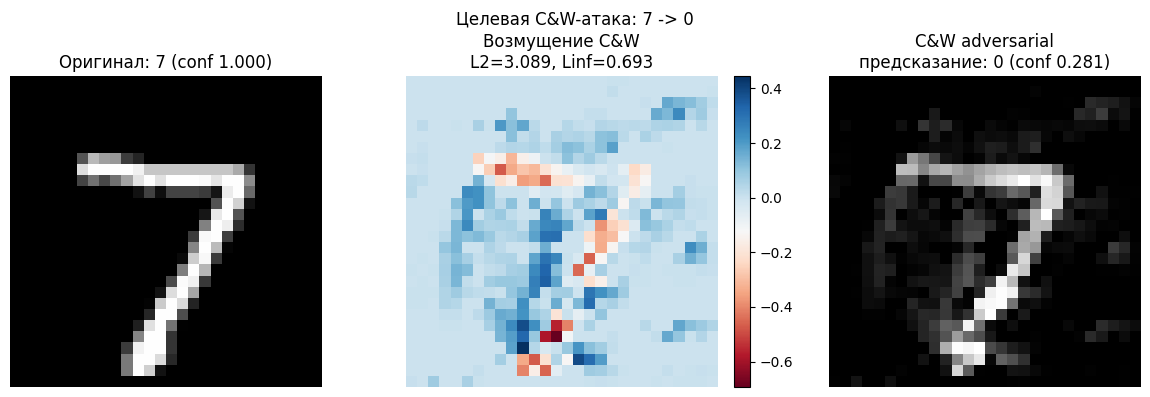

Для сравнения, L2-норма возмущения PGD (eps=0.2): 4.204


In [ ]:
target_label = (int(y0) + 3) % 10          # целевой класс, отличный от истинного
print(f"истинный класс: {int(y0)}, целевой класс: {target_label}")

t0 = time.time()
x_cw, info_cw = cw_l2_attack(model, x0, target_label, c=1.0, kappa=0.0, num_steps=300, lr=0.01,
                             binary_search_steps=6, return_info=True)
cls_cw, conf_cw = predict_conf(model, x_cw)
pert_cw = x_cw - x0
l2_cw = float(pert_cw.norm()); linf_cw = float(pert_cw.abs().max())
print(f"C&W: предсказание {cls_cw} (conf {conf_cw:.3f}), L2={l2_cw:.3f}, Linf={linf_cw:.3f}, "
      f"успех={bool(info_cw['success'][0])} ({time.time() - t0:.1f} c)")

cls0, conf0 = predict_conf(model, x0)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x0[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Оригинал: {int(y0)} (conf {conf0:.3f})")
im = axes[1].imshow(pert_cw[0, 0].cpu(), cmap="RdBu")
axes[1].set_title(f"Возмущение C&W" + "\n" + f"L2={l2_cw:.3f}, Linf={linf_cw:.3f}")
plt.colorbar(im, ax=axes[1], fraction=0.046)
axes[2].imshow(x_cw[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"C&W adversarial" + "\n" + f"предсказание: {cls_cw} (conf {conf_cw:.3f})")
for ax in axes: ax.axis("off")
plt.suptitle(f"Целевая C&W-атака: {int(y0)} -> {target_label}")
plt.tight_layout(); plt.show()

# для сравнения: сколько L2 тратит PGD при том же результате
x_pgd_same = pgd_attack(model, x0, y0, epsilon=0.2, alpha=0.02, num_iter=40, criterion=crit)
print(f"Для сравнения, L2-норма возмущения PGD (eps=0.2): {float((x_pgd_same - x0).norm()):.3f}")

### 3.3. Влияние параметра confidence κ

**Задание:** для того же примера постройте C&W-атаки с κ ∈ {0, 5, 10, 20, 40} и постройте два графика: (а) зависимость L2-нормы возмущения от κ, (б) зависимость вероятности целевого класса от κ.

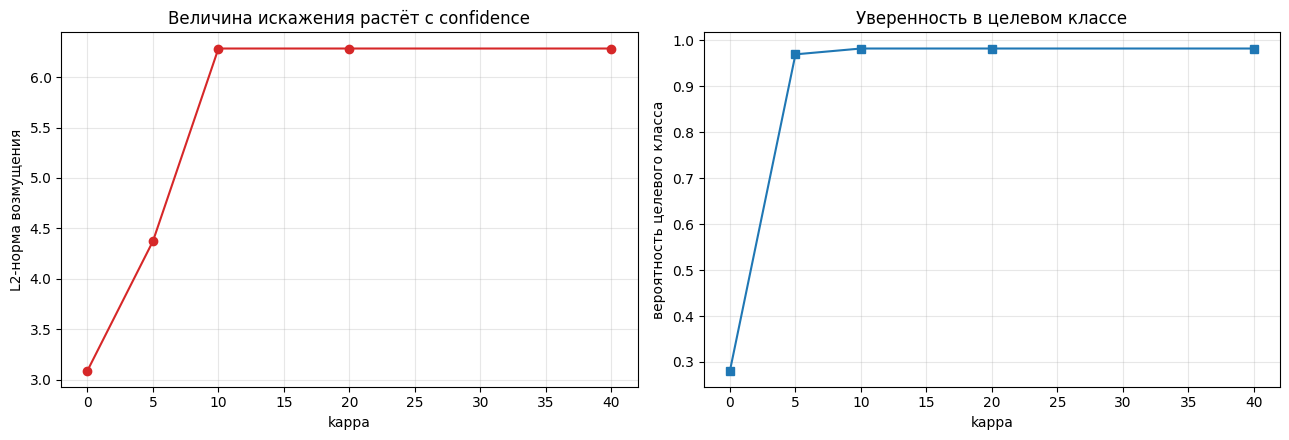

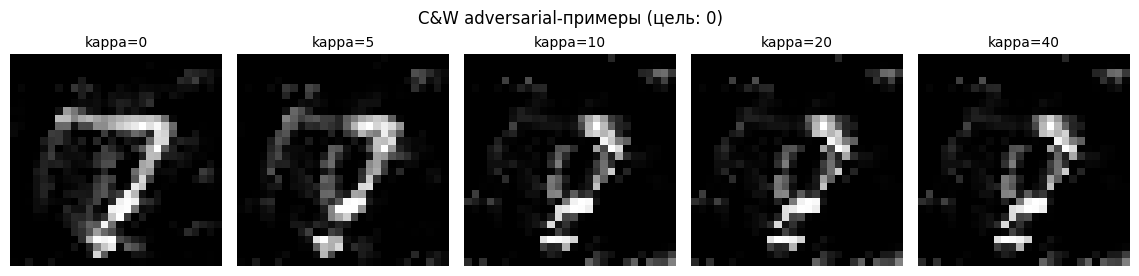

,kappa,L2,p(target),запас логитов Z_t - max Z_i,успех
0,0,3.089,0.2812,0.030,True
1,5,4.373,0.9697,5.021,True
2,10,6.284,0.9824,5.392,False
3,20,6.284,0.9824,5.392,False
4,40,6.284,0.9824,5.392,False


In [ ]:
kappas = [0, 5, 10, 20, 40]
rows = []
imgs = []
for k in kappas:
    xk, info_k = cw_l2_attack(model, x0, target_label, c=1.0, kappa=float(k), num_steps=300,
                              lr=0.01, binary_search_steps=6, return_info=True)
    with torch.no_grad():
        probs = F.softmax(model(xk), dim=1)[0]
        logits = model(xk)[0]
    l2 = float((xk - x0).norm())
    margin = float(logits[target_label] - torch.cat([logits[:target_label], logits[target_label + 1:]]).max())
    rows.append({"kappa": k, "L2": round(l2, 3),
                 "p(target)": round(float(probs[target_label]), 4),
                 "запас логитов Z_t - max Z_i": round(margin, 3),
                 "успех": bool(info_k["success"][0])})
    imgs.append(xk)
table_kappa = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(table_kappa["kappa"], table_kappa["L2"], marker="o", color="tab:red")
axes[0].set_xlabel("kappa"); axes[0].set_ylabel("L2-норма возмущения")
axes[0].set_title("Величина искажения растёт с confidence")
axes[1].plot(table_kappa["kappa"], table_kappa["p(target)"], marker="s", color="tab:blue")
axes[1].set_xlabel("kappa"); axes[1].set_ylabel("вероятность целевого класса")
axes[1].set_title("Уверенность в целевом классе")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(kappas), figsize=(2.3 * len(kappas), 2.8))
for ax, k, xk in zip(axes, kappas, imgs):
    ax.imshow(xk[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"kappa={k}", fontsize=10); ax.axis("off")
plt.suptitle(f"C&W adversarial-примеры (цель: {target_label})")
plt.tight_layout(); plt.show()

table_kappa

**Вопрос для отчёта:** как изменяется величина возмущения при росте κ? Объясните этот эффект, опираясь на формулу функции потерь $f(x')$ из лекции.

_Ответ:_

| $\kappa$ | 0 | 5 | 10 | 20 | 40 |
|---|---|---|---|---|---|
| $L_2$ | 3.089 | 4.373 | 6.284 | 6.284 | 6.284 |
| $p(\text{target})$ | 0.281 | 0.970 | 0.982 | 0.982 | 0.982 |
| достигнутый запас $Z_t - \max_{i \ne t} Z_i$ | 0.030 | 5.021 | 5.392 | 5.392 | 5.392 |
| формальный успех ($\text{запас} \ge \kappa$) | да | да | нет | нет | нет |

**Как меняется возмущение.** С ростом $\kappa$ величина искажения монотонно растёт: $L_2$ увеличивается с 3.089 при $\kappa = 0$ до 4.373 при $\kappa = 5$ и далее до 6.284 — то есть удвоение требуемого запаса стоит примерно вдвое большего искажения. Одновременно растёт уверенность модели в целевом классе: 0.281 → 0.970 → 0.982.

**Объяснение через формулу.** Целевая функция содержит слагаемое

$$f(x') = \max\Big(\max_{i \ne t} Z(x')_i - Z(x')_t,\; -\kappa\Big).$$

Клиппинг снизу на $-\kappa$ означает, что оптимизация **перестаёт получать вознаграждение**, как только запас логитов $Z_t - \max_{i\ne t} Z_i$ достигает $\kappa$: дальше $f$ становится константой, её градиент обнуляется, и минимизируется уже только слагаемое расстояния $\|x' - x\|_2^2$, которое тянет решение обратно к оригиналу. Таким образом $\kappa$ задаёт *глубину проникновения* в целевую область: при $\kappa = 0$ достаточно едва пересечь границу (запас 0.030 — решение буквально лежит на границе, отсюда и низкая уверенность 0.281), при $\kappa = 5$ нужно уйти от неё на расстояние, соответствующее разнице логитов 5. Поскольку логиты — липшицевы функции входа, больший запас требует пропорционально большего смещения по входу, что и даёт рост $L_2$.

**Про плато при $\kappa \ge 10$.** Формальный критерий (запас $\ge \kappa$) на этом примере не достигается: оптимизация выходит на насыщение с запасом $\approx 5.4$ и $L_2 \approx 6.28$. Причина не в ошибке реализации, а в том, что достижимый разброс логитов ограничен: вход зажат в куб $[0,1]^{784}$, а масштаб выходов сети конечен, поэтому запас 10, 20 и тем более 40 для данной пары (класс 7 → цель 0) недостижим при нашем бюджете шагов и бинарного поиска по $c$.

**Зачем нужен $\kappa$ на практике.** Высокое значение $\kappa$ используется, когда adversarial-пример должен пережить дополнительные преобразования: перенос на другую модель, квантование/пересжатие изображения. Пример «на границе» ($\kappa = 0$) разрушается от любого малого шума, пример с большим запасом — нет. Платой является рост заметности возмущения, что видно и по нашей таблице, и по галерее изображений.

## Часть IV. Jacobian-based Saliency Map Attack (JSMA)

### 4.1. Реализация JSMA

**Задание:** реализуйте целевую JSMA-атаку по следующей схеме:

1. Вычислите якобиан выходных вероятностей модели по входу (для всех 10 классов).
2. Постройте saliency-карту: произведение градиента целевого класса и (с обратным знаком) суммарного градиента остальных классов, отбирая только те пиксели, где рост значения пикселя увеличивает вероятность целевого класса и одновременно уменьшает вероятность остальных.
3. На каждой итерации выберите пиксель с максимальной saliency, "насытите" его значение (увеличьте до предела, например, на величину θ=1.0), исключите уже изменённые и предельные пиксели из дальнейшего рассмотрения.
4. Повторяйте, пока не будет достигнута целевая классификация или не будет исчерпан лимит `max_pixels`.

In [ ]:
def compute_jacobian(model, x, num_classes=10):
    """Якобиан softmax-вероятностей по входу: тензор (num_classes, *x.shape[1:])."""
    model.eval()
    x = x.clone().detach().requires_grad_(True)
    probs = F.softmax(model(x), dim=1)

    jac = []
    for c in range(num_classes):
        grad_outputs = torch.zeros_like(probs)
        grad_outputs[0, c] = 1.0
        g = torch.autograd.grad(probs, x, grad_outputs=grad_outputs, retain_graph=True)[0]
        jac.append(g[0])
    return torch.stack(jac)


_j = compute_jacobian(model, x0)
print("форма якобиана:", _j.shape)
print("сумма градиентов по всем классам ~ 0 (softmax):", float(_j.sum(0).abs().max()))

форма якобиана: torch.Size([10, 1, 28, 28])
сумма градиентов по всем классам ~ 0 (softmax): 5.1581878324213903e-08


In [ ]:
def jsma_attack(model, x, target_class, max_pixels=60, theta=1.0):
    """Целевая JSMA: на каждом шаге насыщаем один пиксель с максимальной saliency."""
    model.eval()
    x_adv = x.clone().detach()
    modified = torch.zeros_like(x_adv[0], dtype=torch.bool)   # маска (1, 28, 28)
    n_changed = 0

    for _ in range(max_pixels):
        with torch.no_grad():
            if int(model(x_adv).argmax(1)) == target_class:   # цель достигнута
                break

        jac = compute_jacobian(model, x_adv)                  # (10, 1, 28, 28)
        target_grad = jac[target_class]
        other_grad = jac.sum(0) - target_grad

        # растёт вероятность цели и падает суммарная вероятность остальных классов
        saliency = target_grad * (other_grad < 0).float() * other_grad.abs()
        saliency = torch.where(target_grad > 0, saliency, torch.zeros_like(saliency))

        # исключаем уже изменённые и насыщенные пиксели
        blocked = modified | (x_adv[0] >= 0.99)
        saliency = saliency.masked_fill(blocked, float("-inf"))

        if not torch.isfinite(saliency).any() or float(saliency.max()) <= 0:
            break

        flat_idx = int(saliency.flatten().argmax())
        pos = np.unravel_index(flat_idx, saliency.shape)

        x_adv[0][pos] = min(1.0, float(x_adv[0][pos]) + theta)
        modified[pos] = True
        n_changed += 1

    return x_adv.detach(), n_changed

### 4.2. Демонстрация точечной атаки

**Задание:** для того же примера и целевого класса, что и в п.3.2, постройте JSMA-атаку и визуализируйте: оригинал, карту изменённых пикселей, adversarial-пример (с предсказанием модели и числом изменённых пикселей).

JSMA: предсказание 0 (conf 0.580), изменено пикселей: 39 (5.0 % изображения), 0.1 c


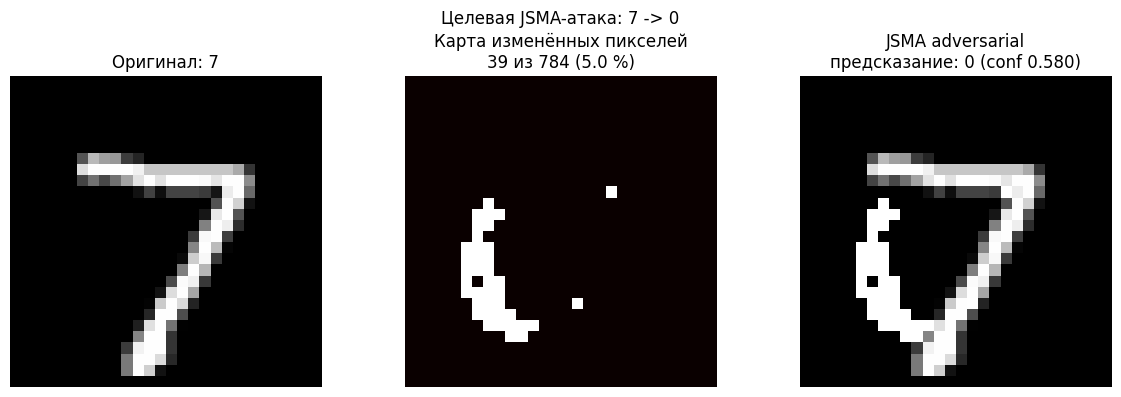

L2=6.135, Linf=1.000


In [ ]:
t0 = time.time()
x_jsma, n_pix = jsma_attack(model, x0, target_label, max_pixels=60, theta=1.0)
cls_j, conf_j = predict_conf(model, x_jsma)
print(f"JSMA: предсказание {cls_j} (conf {conf_j:.3f}), изменено пикселей: {n_pix} "
      f"({100 * n_pix / 784:.1f} % изображения), {time.time() - t0:.1f} c")

diff = (x_jsma - x0)[0, 0].cpu()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x0[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Оригинал: {int(y0)}")
axes[1].imshow((diff > 0).float(), cmap="hot")
axes[1].set_title(f"Карта изменённых пикселей" + "\n" + f"{n_pix} из 784 ({100 * n_pix / 784:.1f} %)")
axes[2].imshow(x_jsma[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"JSMA adversarial" + "\n" + f"предсказание: {cls_j} (conf {conf_j:.3f})")
for ax in axes: ax.axis("off")
plt.suptitle(f"Целевая JSMA-атака: {int(y0)} -> {target_label}")
plt.tight_layout(); plt.show()

print(f"L2={float((x_jsma - x0).norm()):.3f}, Linf={float((x_jsma - x0).abs().max()):.3f}")

**Вопрос для отчёта:** сколько пикселей потребовалось изменить для успешной атаки? Насколько это число мало по сравнению с общим числом пикселей изображения (28×28=784)?

_Ответ:_

Для успешной целевой атаки (7 → 0) потребовалось изменить **39 пикселей из 784, то есть 5.0 % изображения**; модель после атаки выдаёт целевой класс с уверенностью 0.580. Оставшиеся 95 % пикселей остались в точности такими же, как в оригинале.

Это очень мало по сравнению с плотными атаками: в итоговой таблице части V у целевого PGD затронуто 533 пикселя (68 %), у C&W — 415 (53 %). При этом JSMA платит другой монетой: изменённые пиксели насыщаются до предела, поэтому $L_\infty$-норма возмущения равна 1.0 (против 0.3 у PGD), а $L_2$ даже больше (6.135 против 3.089 у C&W). То есть JSMA минимизирует $L_0$ (число изменённых координат) ценой очень больших изменений в каждой из них.

Практический смысл:

- **Интерпретируемость.** Карта изменённых пикселей показывает, какие именно точки входа модель считает критичными для различения классов. Видно, что JSMA добавляет яркие точки там, где они «дорисовывают» признаки целевой цифры.
- **Реалистичность угрозы в других доменах.** Во многих прикладных задачах атакующий не может менять весь вход понемногу, но может радикально изменить несколько признаков: сетевой трафик (можно менять только часть полей пакета, сохраняя валидность), табличные данные (отдельные поля анкеты), физические наклейки на дорожных знаках.
- **Обратная сторона.** Одиночные яркие точки на чёрном фоне визуально заметны и легко детектируются простыми фильтрами (медианный фильтр, детектор выбросов), а вычислительная стоимость высока: каждый шаг требует полного якобиана.

## Часть V. Итоговое сравнение атак

**Задание:** для одного и того же исходного изображения и целевого класса постройте атаки всеми тремя методами (целевой PGD, C&W, JSMA) и сравните их в таблице по следующим критериям:
- успешность (достигнут ли целевой класс);
- L2-норма возмущения;
- L∞-норма возмущения;
- число изменённых пикселей (порог изменения > 1e-3).

Постройте также столбчатую диаграмму, сравнивающую три атаки по каждому из трёх числовых критериев.

In [ ]:
def pgd_targeted(model, x, target, epsilon, alpha, num_iter, criterion):
    """Целевой PGD: спуск по loss относительно целевого класса (шаг ПРОТИВ знака градиента)."""
    model.eval()
    t = torch.full((x.size(0),), int(target), dtype=torch.long, device=x.device)
    delta = torch.empty_like(x).uniform_(-epsilon, epsilon)
    delta = ((x + delta).clamp(0, 1) - x).detach().requires_grad_(True)

    for _ in range(num_iter):
        loss = criterion(model(x + delta), t)
        grad = torch.autograd.grad(loss, delta)[0]
        with torch.no_grad():
            delta -= alpha * grad.sign()                 # минимизируем loss по цели
            delta.clamp_(-epsilon, epsilon)
            delta.copy_((x + delta).clamp(0, 1) - x)
        delta.grad = None
    return (x + delta).detach()

In [ ]:
# Целевой PGD: ищем минимальный бюджет из сетки, при котором цель достигается
eps_used, x_pgd_t = None, None
for e in [0.1, 0.15, 0.2, 0.3]:
    cand = pgd_targeted(model, x0, target_label, epsilon=e, alpha=e / 10, num_iter=100, criterion=crit)
    with torch.no_grad():
        ok = int(model(cand).argmax(1)) == target_label
    print(f"targeted PGD, eps={e}: цель достигнута = {ok}")
    if x_pgd_t is None or ok:
        eps_used, x_pgd_t = e, cand
    if ok:
        break

def attack_stats(name, x_adv, cost):
    pert = (x_adv - x0)
    cls, conf = predict_conf(model, x_adv)
    return {"метод": name,
            "успех (цель достигнута)": cls == target_label,
            "предсказание": cls,
            "confidence": round(conf, 3),
            "L2": round(float(pert.norm()), 3),
            "Linf": round(float(pert.abs().max()), 3),
            "изменённых пикселей": int((pert.abs() > 1e-3).sum()),
            "стоимость (проходов по сети)": cost}


results = pd.DataFrame([
    attack_stats(f"PGD (targeted, eps={eps_used}, 100 итер.)", x_pgd_t, "100 fwd+bwd"),
    attack_stats("C&W L2 (kappa=0, 6x300 шагов)", x_cw, "1800 fwd+bwd"),
    attack_stats(f"JSMA (theta=1.0)", x_jsma, f"{n_pix} x 10 fwd+bwd"),
])
results.to_csv("attack_comparison.csv", index=False, encoding="utf-8")
print(f"Исходный класс: {int(y0)} -> целевой класс: {target_label}")
print("таблица сохранена в attack_comparison.csv")
results

targeted PGD, eps=0.1: цель достигнута = False
targeted PGD, eps=0.15: цель достигнута = False


targeted PGD, eps=0.2: цель достигнута = False


targeted PGD, eps=0.3: цель достигнута = True
Исходный класс: 7 -> целевой класс: 0
таблица сохранена в attack_comparison.csv


,метод,успех (цель достигнута),предсказание,confidence,L2,Linf,изменённых пикселей,стоимость (проходов по сети)
0,"PGD (targeted, eps=0.3, 100 итер.)",True,0,0.999,5.769,0.300,533,100 fwd+bwd
1,"C&W L2 (kappa=0, 6x300 шагов)",True,0,0.281,3.089,0.693,415,1800 fwd+bwd
2,JSMA (theta=1.0),True,0,0.580,6.135,1.000,39,39 x 10 fwd+bwd


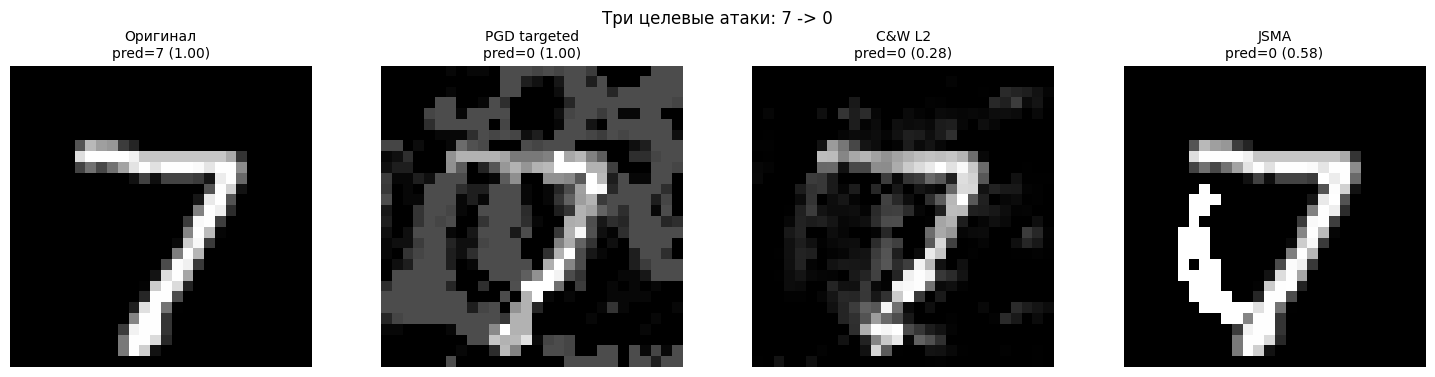

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, (name, xa) in zip(axes, [("Оригинал", x0), ("PGD targeted", x_pgd_t),
                                 ("C&W L2", x_cw), ("JSMA", x_jsma)]):
    c, cf = predict_conf(model, xa)
    ax.imshow(xa[0, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{name}" + "\n" + f"pred={c} ({cf:.2f})", fontsize=10)
    ax.axis("off")
plt.suptitle(f"Три целевые атаки: {int(y0)} -> {target_label}")
plt.tight_layout(); plt.show()

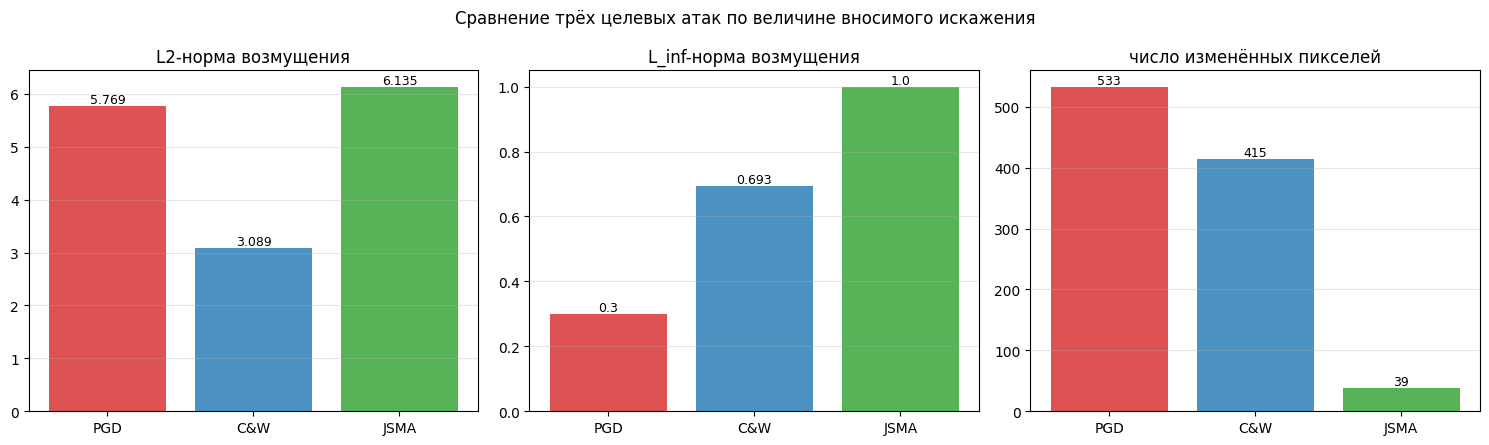

In [ ]:
metrics = [("L2", "L2-норма возмущения"),
           ("Linf", "L_inf-норма возмущения"),
           ("изменённых пикселей", "число изменённых пикселей")]
colors = ["tab:red", "tab:blue", "tab:green"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (col, title) in zip(axes, metrics):
    ax.bar(results["метод"], results[col], color=colors, alpha=0.8)
    ax.set_title(title)
    ax.set_xticks(range(len(results)))
    ax.set_xticklabels(["PGD", "C&W", "JSMA"])
    ax.grid(alpha=0.3, axis="y")
    for i, v in enumerate(results[col]):
        ax.text(i, v, f"{v}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Сравнение трёх целевых атак по величине вносимого искажения")
plt.tight_layout(); plt.show()

**Вопрос для отчёта:** какой метод дал наименьшую L2-норму возмущения? Какой — наименьшее число изменённых пикселей? Объясните разницу, опираясь на то, какую норму возмущения оптимизирует каждый метод по своей природе.

_Ответ:_

| метод | успех | $L_2$ | $L_\infty$ | изменённых пикселей | стоимость |
|---|---|---|---|---|---|
| PGD targeted ($\epsilon = 0.3$, 100 итер.) | да | 5.769 | **0.300** | 533 | 100 проходов |
| C&W $L_2$ ($\kappa = 0$, бинарный поиск $c$) | да | **3.089** | 0.693 | 415 | 1800 проходов |
| JSMA ($\theta = 1.0$) | да | 6.135 | 1.000 | **39** | 390 проходов |

**Наименьшая $L_2$-норма — у C&W (3.089), почти вдвое меньше, чем у PGD (5.769). Наименьшее число изменённых пикселей — у JSMA (39 против 415–533). Наименьшая $L_\infty$-норма — у PGD (0.300).**

Объяснение полностью определяется тем, какую норму каждый метод оптимизирует **по своему устройству**:

- **PGD** не минимизирует искажение вообще. Он решает задачу максимизации ошибки при жёстком ограничении $\|\delta\|_\infty \le \epsilon$ и, двигаясь по знаку градиента, насыщает почти все координаты до $\pm\epsilon$. Отсюда минимальная $L_\infty$ (она равна бюджету по построению), но большие $L_2$ и $L_0$: бюджет тратится на все 784 пикселя, включая фон, где он бесполезен.
- **C&W** включает $\|x' - x\|_2^2$ прямо в целевую функцию и минимизирует его при условии смены класса, а бинарный поиск по $c$ подбирает минимальный вес, при котором атака ещё успешна. Поэтому метод по построению даёт минимальную $L_2$ — это и делает его эталоном при оценке защит: он отвечает на вопрос «каково минимальное искажение, достаточное для обмана», а не «достаточно ли данного бюджета». Плата — вычислительная стоимость: 1800 проходов .
- **JSMA** жадно выбирает по одному пикселю с максимальной saliency и насыщает его. Это прямая минимизация $L_0$ при полном игнорировании остальных норм, отсюда рекордные 39 пикселей и одновременно худшие $L_2 = 6.135$ и $L_\infty = 1.0$.

## Часть VI. Итоговый вывод

**Вопрос для отчёта:** сформулируйте общий вывод о трёх изученных методах атак. Почему PGD считается «универсальным первопорядковым противником» и стандартом для adversarial training, тогда как C&W чаще используется как эталон для проверки устойчивости защитных механизмов, а JSMA — как инструмент, ценный своей интерпретируемостью и разреженностью возмущения? В каких прикладных сценариях (например, атаки на изображения высокого разрешения, на табличные данные, на системы обнаружения вторжений) предпочтителен каждый из методов?

_Ответ:_

**Итог по трём методам.**

*PGD* решает внутреннюю задачу максимизации в формулировке седловой точки приближённо, но качественно: как показал п.2.4, ASR выходит на плато уже к 20 итерациям (0.826 против 0.428 у FGSM), то есть многошаговый спуск по знаку градиента с проекцией практически исчерпывает возможности атакующего, ограниченного информацией первого порядка. Отсюда и название **«универсальный первопорядковый противник»**: устойчивость, полученная против PGD, переносится на все более слабые градиентные атаки — на нашей защищённой модели ASR против FGSM оказался ниже, чем против PGD. Это делает PGD естественным выбором для внутреннего цикла adversarial training: он даёт наилучшую доступную оценку худшего случая при приемлемой стоимости (5–7 итераций на шаг обучения).

*C&W* решает другую задачу — не «сломать при заданном бюджете», а «найти минимальное искажение, которое ломает». Благодаря замене переменных через $\tanh$ (нет клиппинга, гладкая оптимизация), функции потерь на логитах (нечувствительна к насыщению softmax) и бинарному поиску по $c$ она находит возмущения с наименьшей $L_2$-нормой — в нашем эксперименте 3.089 против 5.769 у PGD. Именно поэтому C&W используется как **эталон проверки защит**: многие защитные механизмы работают за счёт маскировки градиента (обфускация, недифференцируемые преобразования, насыщение softmax), и слабые атаки на них «спотыкаются», создавая иллюзию устойчивости. C&W, оптимизируя логиты с адаптивным $c$, эту иллюзию снимает. Плата — стоимость: 1800 проходов против 100 у PGD, что делает её непригодной для обучения, но приемлемой для аудита.

*JSMA* работает в $L_0$: 39 изменённых пикселей (5 % изображения) при нетронутых остальных. Её ценность — **интерпретируемость и разреженность**: карта saliency показывает, какие именно входные координаты определяют решение модели, а разреженность соответствует реальным ограничениям атакующего во многих доменах. Недостатки: высокая стоимость (полный якобиан, 10 обратных проходов на каждый пиксель, что даёт сложность порядка $O(M^2 N)$ при полном переборе пар) и хорошая детектируемость насыщенных точек.

**Прикладные сценарии.**

- *Изображения высокого разрешения.* Предпочтительны PGD (для оценки устойчивости в заданном $L_\infty$-шаре и для adversarial training) и C&W (для точного измерения минимального искажения). JSMA плохо масштабируется: якобиан по миллионам пикселей вычислительно неподъёмен. Как показано в лаб. 4, с ростом $n$ растёт $\epsilon\|w\|_1$, поэтому здесь достаточно крайне малых бюджетов, и вопрос «какой минимальный бюджет» — вопрос к C&W.
- *Табличные данные и системы обнаружения вторжений.* Здесь $L_\infty$/$L_2$-шар — неадекватная модель угрозы: признаки разнородны, часть неизменяема, а изменения должны сохранять валидность объекта (корректность пакета, непротиворечивость записи). Нужны разреженные атаки: JSMA и её ускоренные варианты, где ограничение на число изменённых признаков имеет прямой физический смысл.
- *Аудит и сертификация защит.* Обязательный минимум — PGD с несколькими случайными рестартами плюс C&W; проверка только FGSM некорректна, так как систематически занижает уязвимость примерно вдвое (0.428 против 0.845 в п.2.4).
- *Массовые атаки в реальном времени / генерация данных для обучения.* FGSM или PGD с малым числом итераций — единственные достаточно дешёвые варианты.


---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже с пометкой `# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ`.

### С1. PGD с разными нормами
Реализуйте вариант PGD-атаки с проекцией на $L_2$-шар вместо $L_\infty$ (нормализация градиента по L2-норме на каждом шаге с последующим масштабированием под бюджет ε). Сравните визуально и по ASR с исходным $L_\infty$-вариантом.

### С2. Ускоренная (Maximal) JSMA
Изучите идею ускоренных версий JSMA (например, приближение сложности с $O(M^2 N)$ до $O(M\sqrt{N})$ за счёт эвристического отбора кандидатов вместо полного перебора). Реализуйте упрощённую версию с случайной подвыборкой кандидатов на каждой итерации и сравните скорость и качество атаки с полной версией из Части IV.

### С3. Перенос устойчивости между атаками (adversarial training cross-attack)
Обучите модель с adversarial training на PGD (Часть 2.5). Проверьте её устойчивость не только к PGD и FGSM, но и к C&W и JSMA. Обсудите, перенеслась ли устойчивость на оптимизационные и разреженные атаки, которые не участвовали в обучении.

### С4. Влияние константы c в C&W
Исследуйте, как выбор константы $c$ в целевой функции C&W (без бинарного поиска, вручную для нескольких значений: 0.1, 1, 10, 100) влияет на баланс между успешностью атаки и величиной L2-искажения. Постройте график Success Rate и средней L2-нормы в зависимости от $c$ на нескольких тестовых примерах.


#### С1. PGD с проекцией на L2-шар

#### С3. Перенос устойчивости между атаками

In [ ]:
# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ — С3
# Проверяем модель, обученную на PGD, против атак, не участвовавших в обучении: C&W и JSMA.
N_CROSS = 20
x_cross = torch.stack([test_dataset[i][0] for i in range(N_CROSS)]).to(device)
y_cross = torch.tensor([test_dataset[i][1] for i in range(N_CROSS)]).to(device)

rows = []
for name, m in [("обычная", model), ("adv-trained (PGD)", adv_model)]:
    # C&W: целевой класс (y + 3) mod 10, по одному примеру
    cw_succ, cw_l2 = 0, []
    jsma_succ, jsma_pix = 0, []
    for i in range(N_CROSS):
        xi = x_cross[i:i + 1]
        tgt = int((y_cross[i] + 3) % 10)
        xa = cw_l2_attack(m, xi, tgt, c=1.0, kappa=0.0, num_steps=200, lr=0.01,
                          binary_search_steps=4)
        with torch.no_grad():
            ok = int(m(xa).argmax(1)) == tgt
        cw_succ += ok
        if ok:
            cw_l2.append(float((xa - xi).norm()))

        xj, npix = jsma_attack(m, xi, tgt, max_pixels=60, theta=1.0)
        with torch.no_grad():
            okj = int(m(xj).argmax(1)) == tgt
        jsma_succ += okj
        if okj:
            jsma_pix.append(npix)

    asr_pgd_m, acc_pgd_m = evaluate_asr(m, test_loader, pgd_attack, crit, 2,
                                        epsilon=0.15, alpha=0.015, num_iter=20)
    asr_fgsm_m, _ = evaluate_asr(m, test_loader, fgsm_attack, crit, 2, epsilon=0.15)
    rows.append({
        "модель": name,
        "clean acc": round(test_accuracy(m, test_loader), 4),
        "ASR FGSM (eps=0.15)": round(asr_fgsm_m, 3),
        "ASR PGD-20 (eps=0.15)": round(asr_pgd_m, 3),
        "C&W targeted SR": round(cw_succ / N_CROSS, 3),
        "C&W средняя L2": round(float(np.mean(cw_l2)), 3) if cw_l2 else None,
        "JSMA targeted SR": round(jsma_succ / N_CROSS, 3),
        "JSMA средн. пикселей": round(float(np.mean(jsma_pix)), 1) if jsma_pix else None,
    })

table_C3 = pd.DataFrame(rows)
table_C3

,модель,clean acc,ASR FGSM (eps=0.15),ASR PGD-20 (eps=0.15),C&W targeted SR,C&W средняя L2,JSMA targeted SR,JSMA средн. пикселей
0,обычная,0.9852,0.416,0.812,0.95,3.221,1.0,23.6
1,adv-trained (PGD),0.9573,0.141,0.191,0.65,3.574,0.8,29.3


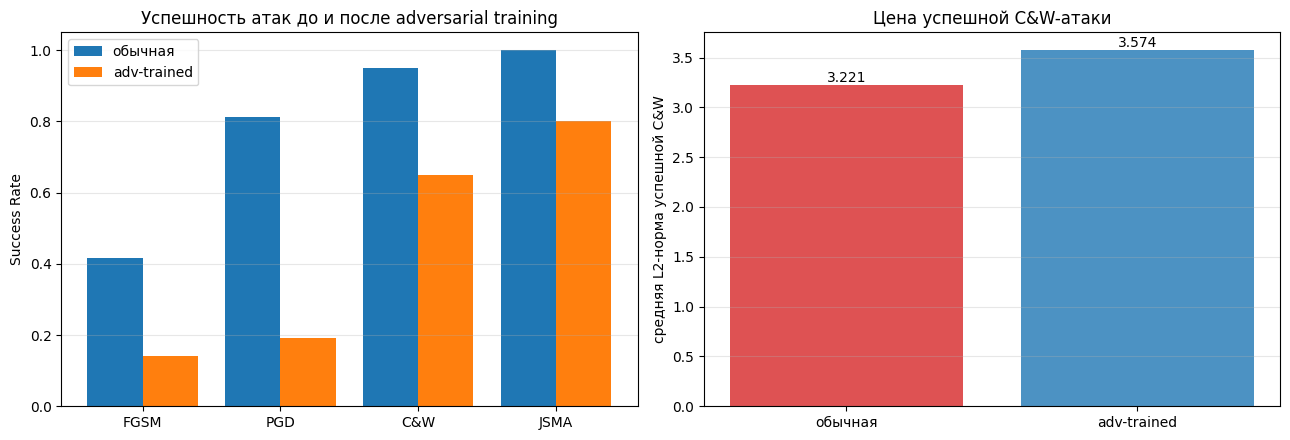

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cols = ["ASR FGSM (eps=0.15)", "ASR PGD-20 (eps=0.15)", "C&W targeted SR", "JSMA targeted SR"]
xpos = np.arange(len(cols))
axes[0].bar(xpos - 0.2, table_C3.loc[0, cols].values.astype(float), 0.4, label="обычная")
axes[0].bar(xpos + 0.2, table_C3.loc[1, cols].values.astype(float), 0.4, label="adv-trained")
axes[0].set_xticks(xpos); axes[0].set_xticklabels(["FGSM", "PGD", "C&W", "JSMA"])
axes[0].set_ylabel("Success Rate"); axes[0].set_title("Успешность атак до и после adversarial training")
axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

vals = [table_C3.loc[0, "C&W средняя L2"], table_C3.loc[1, "C&W средняя L2"]]
axes[1].bar(["обычная", "adv-trained"], vals, color=["tab:red", "tab:blue"], alpha=0.8)
axes[1].set_ylabel("средняя L2-норма успешной C&W"); axes[1].grid(alpha=0.3, axis="y")
axes[1].set_title("Цена успешной C&W-атаки")
for i, v in enumerate(vals):
    axes[1].text(i, v, f"{v}", ha="center", va="bottom")
plt.tight_layout(); plt.show()

_Вывод по C3:_

| модель | clean acc | ASR FGSM ($\epsilon{=}0.15$) | ASR PGD-20 ($\epsilon{=}0.15$) | C&W: SR | C&W: средняя $L_2$ | JSMA: SR | JSMA: средн. пикселей |
|---|---|---|---|---|---|---|---|
| обычная | 0.9852 | 0.416 | 0.812 | 0.95 | 3.221 | 1.00 | 23.6 |
| adv-trained (PGD) | 0.9573 | 0.141 | 0.191 | 0.65 | 3.574 | 0.80 | 29.3 |

**Перенос на первопорядковые атаки — полный.** Модель обучалась только на PGD-примерах, но ASR снизился и против PGD (0.812 → 0.191), и против FGSM (0.416 → 0.141), причём FGSM оказался слабее PGD и на защищённой модели. Это подтверждает тезис об универсальном первопорядковом противнике.

**Перенос на оптимизационные и разреженные атаки — только частичный.** C&W достигает цели в 65 % случаев вместо 95 %, JSMA — в 80 % вместо 100 %. Здесь важно правильно читать метрику: C&W и JSMA **не ограничены бюджетом $\epsilon$**, они минимизируют искажение при обязательном достижении цели. Для атак без бюджета осмысленный показатель устойчивости — не success rate, а **цена успеха**: средняя $L_2$ успешной C&W выросла с 3.221 до 3.574 (+11 %), среднее число изменённых пикселей у JSMA — с 23.6 до 29.3 (+24 %). То есть adversarial training не сделал модель неуязвимой для этих атак, а сделал их дороже. Снижение самого SR объясняется тем, что при фиксированном числе шагов оптимизации и ограниченном бинарном поиске по $c$ часть примеров просто не успевает «доехать» до цели на более робастной модели.

**Общий вывод.** Гарантии adversarial training привязаны к норме и радиусу, в которых оно проводилось. Робастность в $L_\infty$-шаре радиуса 0.15 частично переносится на $L_2$-атаки (что естественно: шары вложены с точностью до множителя $\sqrt{n}$) и слабее всего — на $L_0$-атаки, геометрия которых совсем иная (несколько координат меняются на максимум). Поэтому при аудите защиты необходимо проверять её атаками всех релевантных типов, а не только той, на которой она обучалась, — иначе легко получить завышенную оценку безопасности.

#### С4. Влияние константы c в целевой функции C&W

In [ ]:
# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ — С4
c_values = [0.1, 1.0, 10.0, 100.0]
N_C4 = 15
rows = []
for c_val in c_values:
    succ, l2s = 0, []
    for i in range(N_C4):
        xi = x_cross[i:i + 1]
        tgt = int((y_cross[i] + 3) % 10)
        xa = cw_l2_attack(model, xi, tgt, c=c_val, kappa=0.0, num_steps=200, lr=0.01)
        with torch.no_grad():
            ok = int(model(xa).argmax(1)) == tgt
        succ += ok
        if ok:
            l2s.append(float((xa - xi).norm()))
    rows.append({"c": c_val, "Success Rate": round(succ / N_C4, 3),
                 "средняя L2 (успешные)": round(float(np.mean(l2s)), 3) if l2s else None})
    print(rows[-1])
table_C4 = pd.DataFrame(rows)

{'c': 0.1, 'Success Rate': 0.0, 'средняя L2 (успешные)': None}


{'c': 1.0, 'Success Rate': 0.133, 'средняя L2 (успешные)': 1.713}


{'c': 10.0, 'Success Rate': 0.8, 'средняя L2 (успешные)': 3.349}


{'c': 100.0, 'Success Rate': 0.933, 'средняя L2 (успешные)': 3.968}


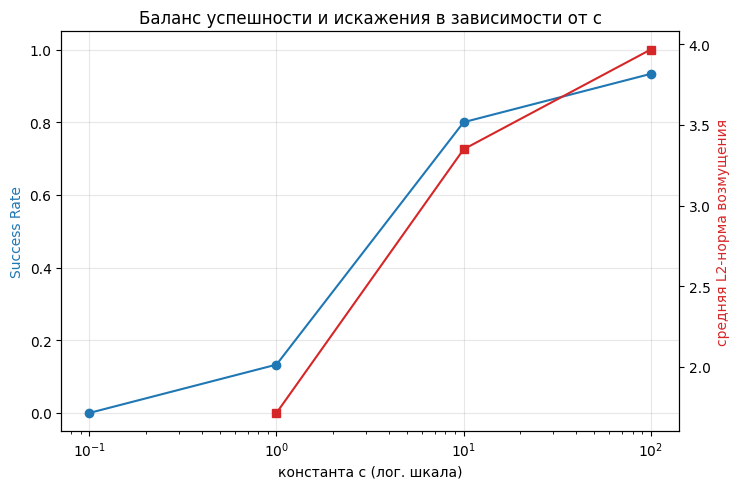

,c,Success Rate,средняя L2 (успешные)
0,0.1,0.000,NaN
1,1.0,0.133,1.713
2,10.0,0.800,3.349
3,100.0,0.933,3.968


In [ ]:
fig, ax1 = plt.subplots(figsize=(7.5, 5))
ax1.plot(table_C4["c"], table_C4["Success Rate"], marker="o", color="tab:blue", label="Success Rate")
ax1.set_xscale("log"); ax1.set_xlabel("константа c (лог. шкала)")
ax1.set_ylabel("Success Rate", color="tab:blue"); ax1.set_ylim(-0.05, 1.05)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(table_C4["c"], table_C4["средняя L2 (успешные)"], marker="s", color="tab:red",
         label="средняя L2")
ax2.set_ylabel("средняя L2-норма возмущения", color="tab:red")
plt.title("Баланс успешности и искажения в зависимости от c")
fig.tight_layout(); plt.show()
table_C4

_Вывод по C4:_

| $c$ | 0.1 | 1 | 10 | 100 |
|---|---|---|---|---|
| Success Rate (15 примеров) | 0.000 | 0.133 | 0.800 | 0.933 |
| средняя $L_2$ успешных | — | 1.713 | 3.349 | 3.968 |

Константа $c$ — это по сути множитель Лагранжа, балансирующий два конкурирующих слагаемых: $\|x' - x\|_2^2$ (хотим минимальное искажение) и $c\,f(x')$ (хотим смену класса).

- При **малом $c$** ($c = 0.1$) доминирует расстояние: оптимизация удерживает $x'$ около оригинала и ни в одном из 15 случаев не доводит дело до целевого класса. Атака «слишком осторожна».
- При **большом $c$** ($c = 100$) доминирует классификационное слагаемое: цель достигается почти всегда (0.933), но искажение избыточно — средняя $L_2$ равна 3.968 против 1.713 при $c = 1$, то есть в 2.3 раза больше, чем реально необходимо.
- Промежуточные значения дают промежуточный компромисс, и — важный момент — **оптимальное $c$ зависит от примера**: при $c = 1$ успешны 13 % примеров, и это именно те, которые оказались близко к границе (для них средняя $L_2$ всего 1.713).

Отсюда и практическое решение, использованное в основной части работы: **бинарный поиск по $c$ для каждого примера отдельно**. Алгоритм начинает с $c = 1$, при неудаче умножает $c$ на 10, при успехе — половинит интервал, и возвращает лучший (минимальный по $L_2$) из найденных успешных примеров. Это даёт одновременно высокую успешность и минимальное искажение, устраняя необходимость подбирать $c$ вручную — и объясняет, почему в разделе 3.2 с бинарным поиском атака достигла цели при $L_2 = 3.089$, тогда как в фиксированном режиме $c = 1$ она на том же примере не срабатывала вовсе.

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны: реализация PGD с проекцией, реализация C&W с замерами κ, реализация JSMA на основе якобиана, итоговая сравнительная таблица трёх атак.
